Datenanalyse mit verschiedenen Modellen für den penguins-Datensatz

Entscheiden Sie sich für je ein Verfahren der: 
• Regressionsanalyse 
• Cluster-Analyse 
• neuronalen Netzwerkes 

In [1]:
#bibliotheken
import pandas as pd

In [2]:
#Dataset laden
df = pd.read_csv('penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
#info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
#before Verarbeitung versuchen Speicherplatz zu reduzieren
num_spalten = df.select_dtypes(include='number').columns
print(num_spalten)
df1=pd.DataFrame()
for i in num_spalten:
    #df1 = df.apply(pd.to_numeric,downcast='float')
    df[[i]] = df[[i]].apply(pd.to_numeric,downcast='float')
print(df.info())

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float32
 3   bill_depth_mm      342 non-null    float32
 4   flipper_length_mm  342 non-null    float32
 5   body_mass_g        342 non-null    float32
 6   sex                333 non-null    str    
dtypes: float32(4), str(3)
memory usage: 13.6 KB
None


In [6]:
#Datenbereinigung

df.isna().sum()    #NaN Werte

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [9]:
#Zeile mit NaN entfernen
df.dropna(inplace=True)
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [10]:
#Inkonsistente Werte prüfen
for i in ['sex','species','island']:
    print(df[i].unique())

<StringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str
<StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str
<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str


In [11]:
#noch categories erstellen???
#nicht numerische spalten
string_spalten = df.select_dtypes(include='string')
for i in string_spalten:
    df[i] = df[i].astype("category")
df.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            333 non-null    category
 1   island             333 non-null    category
 2   bill_length_mm     333 non-null    float32 
 3   bill_depth_mm      333 non-null    float32 
 4   flipper_length_mm  333 non-null    float32 
 5   body_mass_g        333 non-null    float32 
 6   sex                333 non-null    category
dtypes: category(3), float32(4)
memory usage: 8.8 KB


In [ ]:
#Barplots für Ausreißer
import matplotlib.pyplot as plt

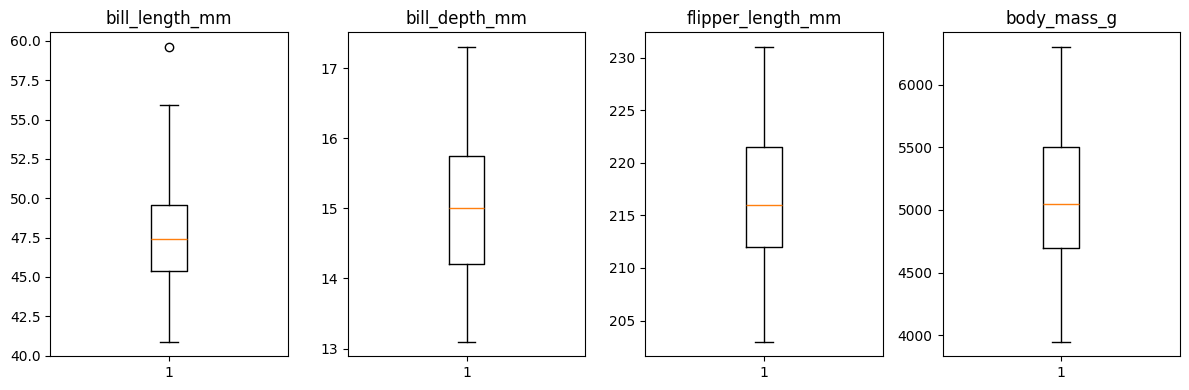

In [25]:
#nur bestimmte species
df_spec = df[df['species']=='Gentoo']
# 1 Zeile, 4 Spalten
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(len(num_spalten)):
    axes[i].boxplot(df_spec[num_spalten[i]])
    axes[i].set_title(num_spalten[i])

plt.tight_layout()
plt.show()

kNN Analyse.
Zu welchem Klasse gehoert neues Penguin

In [26]:
# bibliotheken laden
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import numpy as np

In [74]:
df_num=df[num_spalten]

#X array, merkmale
X = df_num.values

y = df['species'].values  #klassen

y_names = y.unique()
print(X)
print(y)

[[  39.1   18.7  181.  3750. ]
 [  39.5   17.4  186.  3800. ]
 [  40.3   18.   195.  3250. ]
 ...
 [  50.4   15.7  222.  5750. ]
 [  45.2   14.8  212.  5200. ]
 [  49.9   16.1  213.  5400. ]]
['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', ..., 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo']
Length: 333
Categories (3, str): ['Adelie', 'Chinstrap', 'Gentoo']


In [75]:
print("Feature-Namen", num_spalten)
print("Klassen:", y_names)
print("Anzahl Daten:", len(X))

Feature-Namen Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')
Klassen: ['Adelie', 'Chinstrap', 'Gentoo']
Categories (3, str): ['Adelie', 'Chinstrap', 'Gentoo']
Anzahl Daten: 333


In [76]:
# Wir teilen die Daten 80% Training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [55]:
#Nachbarn
k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_predict = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_predict)
print("Genauigkeit:",accuracy)

Genauigkeit: 0.8208955223880597


In [66]:
# new_penguin = np.array([[37,18.9,187,3120]]) #+-Adelie
new_penguin = np.array([[46,17.3,186,3640]]) #+-Chinstrap


prediction = knn.predict(new_penguin)

# print(prediction)
print("Vorhersagte Klasse:", prediction[0])

Vorhersagte Klasse: Chinstrap


Regressionsanalyse

In [67]:
#modul importieren
from sklearn.linear_model import LinearRegression

In [80]:
#Regressionsmodelle für Adelie(großte Klasse)
num_spalten #numerische Spalten von df

df_adel = df[df['species'] == 'Adelie']
X = df_adel[num_spalten].drop(columns='body_mass_g')  #bill_lenght,depth,flipper_lenght
y = df_adel['body_mass_g']          #Masse

model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:


#Vorhersage
y_pred = model.predict(X)

#Ergebnisse
erg = pd.DataFrame({'Original Mass': y, 'Predicted Mass':y_pred})
print(erg)

     Original Mass  Predicted Mass
0           3750.0     3618.090820
1           3800.0     3537.065918
2           3250.0     3819.402344
4           3450.0     3776.732422
5           3650.0     4055.123047
..             ...             ...
147         3475.0     3489.306641
148         3450.0     3556.167969
149         3750.0     3663.708008
150         3700.0     3319.940430
151         4000.0     4058.384766

[146 rows x 2 columns]


In [84]:
#wenn Koeffizient ist Positiv -> Koerpergewicht steigt
#wenn Koeffizient ist Negativ -> Koerpergewicht sinkt

print(model.coef_)

# coeff_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Coefficient': model.coef_
# })
# print(coeff_df)

[ 54.51243 144.15668  16.91478]


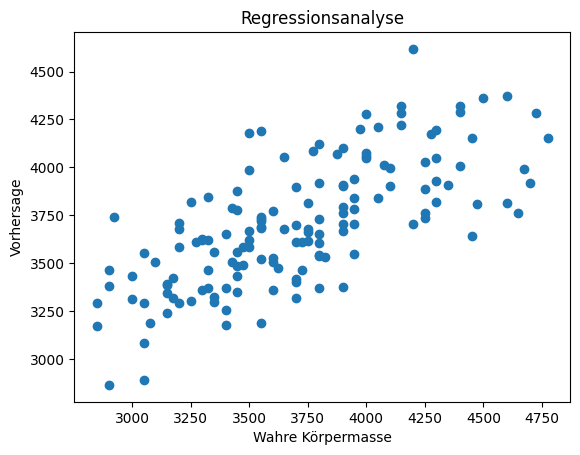

In [85]:
plt.scatter(y, y_pred)
plt.xlabel("Wahre Körpermasse")
plt.ylabel("Vorhersage")
plt.title("Regressionsanalyse")
plt.show()

Cluster-Analyse

In [88]:
#df numerische Spalten
X_clust = df[num_spalten]
df_clust = df

#Data skalieren
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

In [98]:
#K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
df_clust['cluster'] = labels
print(df_clust.head())
# print(labels)

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen       39.099998      18.700001              181.0   
1  Adelie  Torgersen       39.500000      17.400000              186.0   
2  Adelie  Torgersen       40.299999      18.000000              195.0   
4  Adelie  Torgersen       36.700001      19.299999              193.0   
5  Adelie  Torgersen       39.299999      20.600000              190.0   

   body_mass_g     sex  cluster  
0       3750.0    MALE        0  
1       3800.0  FEMALE        0  
2       3250.0  FEMALE        0  
4       3450.0  FEMALE        0  
5       3650.0    MALE        0  


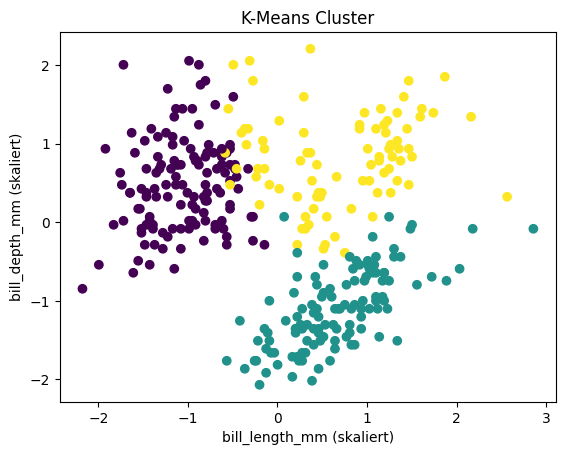

In [99]:
#Visualisieren

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis') #erste und zweite Spalten von X_scaled
plt.xlabel("bill_length_mm (skaliert)") #erste Spalte
plt.ylabel("bill_depth_mm (skaliert)")  #zweite Spalte
plt.title("K-Means Cluster")
plt.show()

Neuronale Netzwerke

In [103]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

In [ ]:
#merkmale
X_nn = df[num_spalten]
#arten
y_nn = df['species']


model_nn = models.Sequential([
    layers.Input(shape=(X_nn.shape[1],)),   #hier (4,), weil es 4 numerische Spalten gibt
    layers.Dense(8, activation="relu"),  
    layers.Dense(4, activation="relu"),
    layers.Dense(3, activation='softmax')   #3 Neuronen für 3 Klassen
])

model_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [109]:
#Skalierung verbessert NN!
X_nn_scaled = scaler.fit_transform(X_nn)

#Encoding von labels
le = LabelEncoder()
y_enc = le.fit_transform(y_nn)

#Modell trainieren
model_nn.fit(X_scaled, y_enc, epochs=50, batch_size=8, shuffle=True)  #gleichzeitlich 8 Punkte bearbeitet

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9940 - loss: 0.0177
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0173
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0176 
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0167
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0165
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0163
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0159   
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0157   
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0155   
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0153
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0154
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1

In [112]:
#Vorhersage
pred = model_nn.predict(X_scaled)  # Wahrscheinlichkeiten von jeder Klass
pred_class = pred.argmax(axis=1) #Maximale Wahrscheinlichkeit 

# zurück zu Labels
y_nn_pred = le.inverse_transform(pred_class)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [113]:
from sklearn.metrics import confusion_matrix
import itertools

#Genauigkeit von Vorhersage

cm = confusion_matrix(y_true=y_nn,y_pred=y_nn_pred)
print(cm,"\n")

[[146   0   0]
 [  0  68   0]
 [  0   0 119]] 



In [114]:
#Matrix Visualisierung

# selber Funktion
def plot_confusion_matrix(cm, classes, normalize=False,
                          title="Confusion matrix",
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting 'normalize=True'.
    """

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix ohne normalization")
    
    print(cm)

    thresh = cm.max()/2   # Schwellenwert
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                 horizontalalignment='center',
                 color = 'white' if cm[i,j] > thresh else 'black')
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')  



Confusion matrix ohne normalization
[[146   0   0]
 [  0  68   0]
 [  0   0 119]]


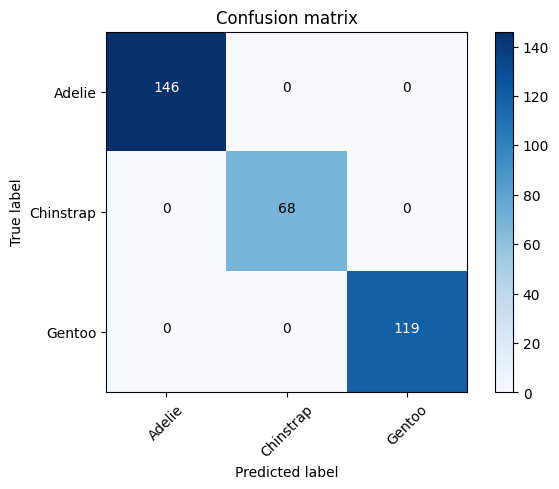

In [ ]:
#Visualisierung
plot_confusion_matrix(cm=cm, classes=y_names)

#er hat allen Werte die richtige Klasse gegeben???
